In [1]:
import os
os.environ["NUMBA_DISABLE_JIT"] = "1"

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from data.data_processor_fix import DataProcessor as DP
from data.splitter import SurvivalSplitter
from data.RFMFeatures import RFMFeatures
from models.cox_model_upd import CoxModelUpd
from models.rsf_model import RSFModel
from metrics.ibs import IBSMetric
from metrics.auprc import AUPRCMetric
from metrics.evaluator import SurvivalEvaluator
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [2]:
df = pd.read_csv('data/individual_custody_timeline_rfm.csv')
df.info()
#print(df.columns)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18668 entries, 0 to 18667
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   name                     18668 non-null  object 
 1   age                      18668 non-null  int64  
 2   sex                      18668 non-null  object 
 3   race                     18668 non-null  object 
 4   c_charge_degree          17883 non-null  object 
 5   c_charge_desc            17870 non-null  object 
 6   in_custody               18074 non-null  object 
 7   out_custody              18074 non-null  object 
 8   custody_num              18668 non-null  int64  
 9   time_to_last_custody     7797 non-null   float64
 10  time_since_last_arrest   7797 non-null   float64
 11  time_to_future_arrest    7797 non-null   float64
 12  event                    18668 non-null  int64  
 13  event_of_future_arrest   18668 non-null  int64  
 14  curr_dur_custody      

In [3]:
processor = DP("data/individual_custody_timeline_rfm.csv")
cox_df = processor.load_and_prepare()
cox_df['c_charge_degree'] = cox_df['c_charge_degree'].str.strip('()')
cox_df['race'] = cox_df['race'].str.strip('').str.upper()
cox_df['sex'] = cox_df['sex'].str.strip().str.upper()
sex_mapping = {
    'MALE': 0,
    'FEMALE': 1
}
cox_df['sex'] = cox_df['sex'].map(sex_mapping)
cox_df.head()
cox_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7772 entries, 0 to 7771
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   name                    7772 non-null   object 
 1   episode_col             7772 non-null   int64  
 2   start                   7772 non-null   float64
 3   stop                    7772 non-null   float64
 4   event                   7772 non-null   int64  
 5   age                     7772 non-null   int64  
 6   sex                     7772 non-null   int64  
 7   race                    7772 non-null   object 
 8   c_charge_degree         7667 non-null   object 
 9   time_since_last_arrest  7772 non-null   float64
 10  average_dur_custody     7772 non-null   float64
 11  curr_dur_custody        7772 non-null   float64
dtypes: float64(5), int64(4), object(3)
memory usage: 728.8+ KB


In [4]:
features_for_rfm = ["curr_dur_custody", "time_since_last_arrest"]
operations = ["min", "max", "mean"]

rfm = RFMFeatures(id_col="name", episode_col="episode_col")
cox_df = rfm.create(
    df=cox_df,
    history_features=features_for_rfm,
    operations=operations
)

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [5]:
cox_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7772 entries, 0 to 7771
Data columns (total 24 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   name                            7772 non-null   object 
 1   episode_col                     7772 non-null   int64  
 2   start                           7772 non-null   float64
 3   stop                            7772 non-null   float64
 4   event                           7772 non-null   int64  
 5   age                             7772 non-null   int64  
 6   sex                             7772 non-null   int64  
 7   race                            7772 non-null   object 
 8   c_charge_degree                 7667 non-null   object 
 9   time_since_last_arrest          7772 non-null   float64
 10  average_dur_custody             7772 non-null   float64
 11  curr_dur_custody                7772 non-null   float64
 12  curr_dur_custody_history        77

Data split into train and test data

In [6]:
splitter = SurvivalSplitter(test_size=0.2)
train_df, test_df = splitter.split_by_individual(cox_df)
train_df = train_df.drop(columns=["curr_dur_custody"])
test_df = test_df.drop(columns=["curr_dur_custody"])
train_df["time"] = train_df["stop"] - train_df["start"]
test_df["time"] = test_df["stop"] - test_df["start"]

print("Train individuals:", train_df["name"].nunique())
print("Test individuals:", test_df["name"].nunique())

Train individuals: 3382
Test individuals: 845


In [7]:
ohe = OneHotEncoder(
    drop='first',
    sparse_output=True,
    handle_unknown='ignore'
)

categorical_cols = ['c_charge_degree', 'race']
ohe.fit(train_df[categorical_cols])

train_encoded = ohe.transform(train_df[categorical_cols])
test_encoded = ohe.transform(test_df[categorical_cols])
train_encoded_dense = train_encoded.toarray()
test_encoded_dense = test_encoded.toarray()

encoded_cols = ohe.get_feature_names_out(categorical_cols)
train_encoded_df = pd.DataFrame(train_encoded_dense, columns=encoded_cols, index=train_df.index)
test_encoded_df = pd.DataFrame(test_encoded_dense, columns=encoded_cols, index=test_df.index)

train_df = train_df.drop(columns=categorical_cols)
test_df = test_df.drop(columns=categorical_cols)

train_df = pd.concat([train_df, train_encoded_df], axis=1)
test_df = pd.concat([test_df, test_encoded_df], axis=1)

In [8]:
train_df.query("name=='daniel diaz'")

,name,episode_col,start,stop,event,age,sex,time_since_last_arrest,average_dur_custody,curr_dur_custody_history,...,c_charge_degree_M1,c_charge_degree_M2,c_charge_degree_MO3,c_charge_degree_NI0,c_charge_degree_nan,race_ASIAN,race_CAUCASIAN,race_HISPANIC,race_NATIVE AMERICAN,race_OTHER
1171,daniel diaz,1,0.0,104.0,1,50,0,70.0,34.00,[],...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1172,daniel diaz,2,104.0,159.0,1,50,0,24.0,32.50,[31.0],...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1173,daniel diaz,3,159.0,235.0,1,50,0,12.0,43.00,"[31.0, 64.0]",...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1174,daniel diaz,4,235.0,261.0,1,50,0,25.0,32.50,"[31.0, 64.0, 1.0]",...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1175,daniel diaz,5,261.0,391.0,1,50,0,12.0,49.60,"[31.0, 64.0, 1.0, 118.0]",...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1176,daniel diaz,6,391.0,1079.0,1,50,0,509.0,71.17,"[31.0, 64.0, 1.0, 118.0, 179.0]",...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1177,daniel diaz,7,1079.0,1088.0,1,50,0,7.0,61.29,"[31.0, 64.0, 1.0, 118.0, 179.0, 2.0]",...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1178,daniel diaz,8,1088.0,1128.0,0,50,0,6.0,57.88,"[31.0, 64.0, 1.0, 118.0, 179.0, 2.0, 34.0]",...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [9]:
features = [c for c in train_df.columns 
            if c not in ["name", "start", "time", "event", "stop"]
            and not c.endswith("_history")]

cols_for_model = ["name", "start", "stop", "event", "time"] + features
train_model_df = train_df[cols_for_model].copy().fillna(-1)
test_df = test_df.fillna(-1)

In [10]:
display(train_model_df.groupby("episode_col").size())
display(test_df.groupby("episode_col").size())

episode_col
1     3382
2     1503
3      680
4      304
5      148
6       77
7       37
8       11
9        5
10       2
dtype: int64

episode_col
1     845
2     435
3     184
4      78
5      34
6      16
7      13
8       5
9       4
10      4
11      3
12      2
dtype: int64

In [11]:
test_model_df = test_df.query(f"episode_col.isin({train_model_df['episode_col'].unique().tolist()})")

In [12]:
horizon = np.quantile(train_model_df["stop"] - train_model_df["start"], 0.95)
times = np.linspace(0, horizon, 200)

In [13]:
# models = {}

# for model_mode in ["recurrent", "independent"]:
#     for use_episode in [True, False]:
#         for penalizer in [0.0, 0.01, 0.1]:
#             name = f"CoxUpd_{model_mode[:3]}_{'with' if use_episode else 'no'}_k_pen_{penalizer}"
#             print(name)
#             features_model = features.copy()
#             if not(use_episode):
#                 features_model.remove("episode_col")

#             model = CoxModelUpd(
#                 features=features_model,
#                 mode=model_mode,
#                 use_episode=use_episode,
#                 penalizer=penalizer    
#             )
#             if model_mode == "recurrent":
#                 model.fit(train_model_df[features_model + ["start", "stop", "name", "event"]])
#             else:
#                 model.fit(train_model_df[features_model + ["time", "event"]])
#             model.features = features_model
#             models[name] = model

# features_rsf = features.copy()
# features_rsf.remove("episode_col")
# train_rsf_df = train_df[["time","event"] + features_rsf].copy()
# rsf_model = RSFModel(features=features_rsf)
# rsf_model.fit(train_rsf_df)
# rsf_model.features = features_rsf
# models["RSF_no_episode_col"] = rsf_model

In [14]:
from sklearn.model_selection import ParameterGrid

models_grid = {
    "CoxUpd_rec": {'model': CoxModelUpd, 'mode': 'recurrent', 
                   'hyperparams_grid': {'use_episode': [True, False], 'penalizer': [0.1]}},
    "CoxUpd_ind": {'model': CoxModelUpd, 'mode': 'independent', 
                   'hyperparams_grid': {'use_episode': [True, False], 'penalizer': [0.0, 0.1]}},
    "RSF_ind": {'model': RSFModel, 'mode': 'independent',
                'hyperparams_grid': {'use_episode': [True, False], 'n_estimators': [100, 200], 'min_samples_split': [2]}}
}

models = {}

for mdl in models_grid.keys():
    model_proto = models_grid[mdl]
    for params in ParameterGrid(model_proto['hyperparams_grid']):
        name = f"{mdl}_{'_'.join([f'{k}_{v}' for k, v in params.items()])}"
        print(name)
        features_model = features.copy()
        if not(params['use_episode']):
            features_model.remove("episode_col")

        model = model_proto['model'](
            features=features_model,
            mode=model_proto['mode'],
            **params
        )
        if model_proto['mode'] == "recurrent":
            model.fit(train_model_df[features_model + ["start", "stop", "name", "event"]])
        else:
            model.fit(train_model_df[features_model + ["time", "event"]])
        models[name] = model

CoxUpd_rec_penalizer_0.1_use_episode_True


model,lifelines.CoxPHFitter
duration col,'stop'
event col,'event'
entry col,'start'
cluster col,'name'
penalizer,0.1
l1 ratio,0.0
robust variance,True
strata,episode_col
baseline estimation,breslow
number of observations,6149


<class 'lifelines.fitters.coxph_fitter.CoxPHFitter'>
CoxUpd_rec_penalizer_0.1_use_episode_False


model,lifelines.CoxPHFitter
duration col,'stop'
event col,'event'
entry col,'start'
cluster col,'name'
penalizer,0.1
l1 ratio,0.0
robust variance,True
baseline estimation,breslow
number of observations,6149
number of events observed,2767


<class 'lifelines.fitters.coxph_fitter.CoxPHFitter'>
CoxUpd_ind_penalizer_0.0_use_episode_True


...

<class 'lifelines.fitters.coxph_fitter.CoxPHFitter'>
CoxUpd_ind_penalizer_0.1_use_episode_True


<lifelines.CoxPHFitter: fitted with 6149 total observations, 3382 right-censored observations>
             duration col = 'time'
                event col = 'event'
                penalizer = 0.1
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 6149
number of events observed = 2767
   partial log-likelihood = -20162.41
         time fit was run = 2026-03-24 08:54:34 UTC

---
                             coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                    
episode_col                  0.12      1.12      0.02            0.08            0.15                1.09                1.16
age                         -0.01      0.99      0.00           -0.01           -0.00                0.99                1.00
sex                         -0.08      0.92      0.05           -0.18            0.02                0.84                1.02
time_since_last_arrest      -0.01      0.99      0.00           -0.01           -0.01                0.99                0.99
average_dur_custody         -0.01      0.99      0.00           -0.01           -0.01                0.99                0.99
curr_dur_custody_min        -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
curr_dur_custody_max        -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
curr_dur_custody_mean       -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
time_since_last_arrest_min  -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
time_since_last_arrest_max  -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
time_since_last_arrest_mean -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
log_curr_dur_custody        -0.02      0.98      0.01           -0.05           -0.00                0.95                1.00
dur_deviation_from_avg      -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
custody_increasing           0.36      1.43      0.05            0.26            0.45                1.30                1.57
arrest_speed_trend          -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
c_charge_degree_F1          -0.10      0.90      0.16           -0.41            0.21                0.67                1.23
c_charge_degree_F2          -0.06      0.94      0.08           -0.21            0.08                0.81                1.09
c_charge_degree_F3           0.06      1.06      0.06           -0.05            0.18                0.95                1.19
c_charge_degree_F5          -1.38      0.25      1.18           -3.70            0.94                0.02                2.55
c_charge_degree_F6           0.21      1.24      0.65           -1.06            1.49                0.35                4.42
c_charge_degree_F7          -0.02      0.98      0.18           -0.37            0.34                0.69                1.40
c_charge_degree_M1          -0.11      0.89      0.07           -0.25            0.02                0.78                1.02
c_charge_degree_M2          -0.06      0.94      0.08           -0.23            0.10                0.80                1.10
c_charge_degree_MO3          0.29      1.34      0.19           -0.07            0.66                0.93                1.94
c_charge_degree_NI0         -0.05      0.96      0.63           -1.28            1.19                0.28                3.30
c_charge_degree_nan          0.31      1.36      0.15            0.01            0.61                1.01                1.84
race_ASIAN                  -0.91      0.40  

<class 'lifelines.fitters.coxph_fitter.CoxPHFitter'>
CoxUpd_ind_penalizer_0.1_use_episode_False


<lifelines.CoxPHFitter: fitted with 6149 total observations, 3382 right-censored observations>
             duration col = 'time'
                event col = 'event'
                penalizer = 0.1
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 6149
number of events observed = 2767
   partial log-likelihood = -20184.46
         time fit was run = 2026-03-24 08:54:34 UTC

---
                             coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                    
age                         -0.01      0.99      0.00           -0.01           -0.00                0.99                1.00
sex                         -0.08      0.93      0.05           -0.17            0.02                0.84                1.02
time_since_last_arrest      -0.01      0.99      0.00           -0.01           -0.01                0.99                0.99
average_dur_custody         -0.01      0.99      0.00           -0.01           -0.01                0.99                0.99
curr_dur_custody_min        -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
curr_dur_custody_max        -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
curr_dur_custody_mean       -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
time_since_last_arrest_min  -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
time_since_last_arrest_max  -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
time_since_last_arrest_mean -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
log_curr_dur_custody        -0.03      0.97      0.01           -0.05           -0.01                0.95                0.99
dur_deviation_from_avg      -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
custody_increasing           0.42      1.53      0.05            0.33            0.52                1.39                1.68
arrest_speed_trend          -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
c_charge_degree_F1          -0.10      0.90      0.16           -0.41            0.20                0.66                1.23
c_charge_degree_F2          -0.08      0.92      0.08           -0.23            0.07                0.80                1.07
c_charge_degree_F3           0.07      1.07      0.06           -0.05            0.18                0.95                1.20
c_charge_degree_F5          -1.40      0.25      1.18           -3.71            0.91                0.02                2.47
c_charge_degree_F6           0.18      1.20      0.65           -1.09            1.45                0.34                4.25
c_charge_degree_F7          -0.03      0.97      0.18           -0.38            0.33                0.68                1.39
c_charge_degree_M1          -0.12      0.89      0.07           -0.25            0.02                0.78                1.02
c_charge_degree_M2          -0.06      0.94      0.08           -0.23            0.10                0.80                1.11
c_charge_degree_MO3          0.31      1.36      0.19           -0.06            0.68                0.94                1.97
c_charge_degree_NI0         -0.09      0.92      0.63           -1.32            1.15                0.27                3.15
c_charge_degree_nan          0.34      1.40      0.15            0.04            0.64                1.04                1.89
race_ASIAN                  -0.93      0.39      0.63           -2.16            0.30                0.12                1.34
race_CAUCASIAN              -0.11      0.90  

<class 'lifelines.fitters.coxph_fitter.CoxPHFitter'>
RSF_ind_min_samples_split_2_n_estimators_100_use_episode_True
RSF_ind_min_samples_split_2_n_estimators_100_use_episode_False
RSF_ind_min_samples_split_2_n_estimators_200_use_episode_True
RSF_ind_min_samples_split_2_n_estimators_200_use_episode_False


In [15]:
evaluator = SurvivalEvaluator(
    ibs_metric=IBSMetric(),
    auprc_metric=AUPRCMetric()
)

for name, model in models.items():
    evaluator.evaluate(
        model=model,
        model_name=name,
        train_df=train_model_df,
        test_df=test_model_df,
        features=model.features,
        times=times
    )

evaluator.get_results_table().round(4)

,model,IBS,AUPRC,C-index,recurrent_error,IAUC_RE1,IAUC_RE2,IAUC_RE3
0,CoxUpd_rec_penalizer_0.1_use_episode_True,0.2681,0.5969,0.4954,1.1074,0.7636,0.6391,0.4819
1,CoxUpd_rec_penalizer_0.1_use_episode_False,0.1262,0.6511,0.8673,0.8336,0.8726,0.8873,0.7940
2,CoxUpd_ind_penalizer_0.0_use_episode_True,0.0145,0.8428,0.9638,1.4224,0.8516,0.9289,0.7926
3,CoxUpd_ind_penalizer_0.0_use_episode_False,0.0150,0.8408,0.9628,1.4231,0.8504,0.9283,0.7928
4,CoxUpd_ind_penalizer_0.1_use_episode_True,0.0471,0.7017,0.9312,0.8979,0.8901,0.9039,0.7933
5,CoxUpd_ind_penalizer_0.1_use_episode_False,0.0476,0.7000,0.9307,0.9333,0.8888,0.9023,0.7934
6,RSF_ind_min_samples_split_2_n_estimators_100_u...,0.0698,0.7149,0.9093,0.5714,0.9059,0.9478,0.8002
7,RSF_ind_min_samples_split_2_n_estimators_100_u...,0.0650,0.7258,0.9125,0.5813,0.9049,0.9530,0.8026
8,RSF_ind_min_samples_split_2_n_estimators_200_u...,0.0673,0.7207,0.9117,0.5154,0.9054,0.9501,0.8000
9,RSF_ind_min_samples_split_2_n_estimators_200_u...,0.0652,0.7248,0.9142,0.5828,0.9055,0.9481,0.8001


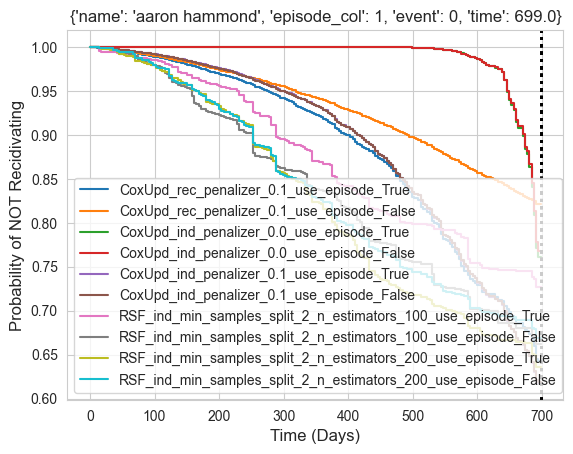

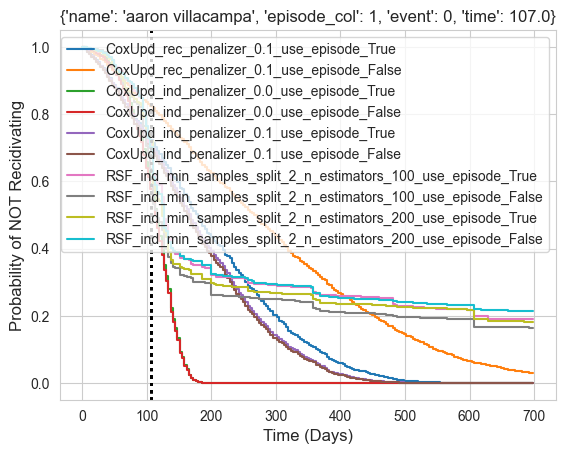

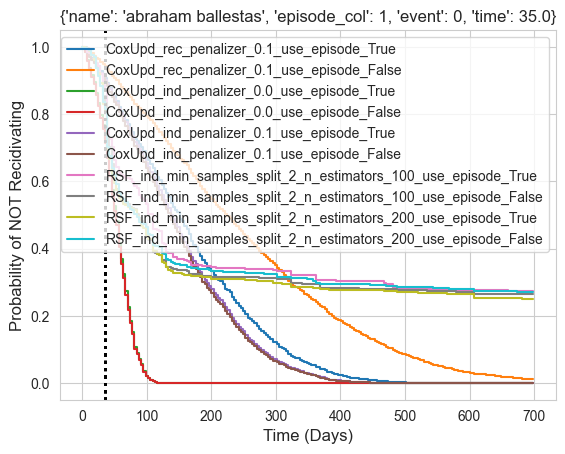

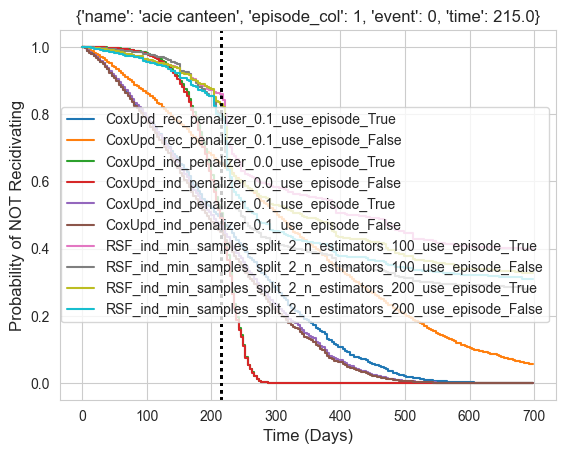

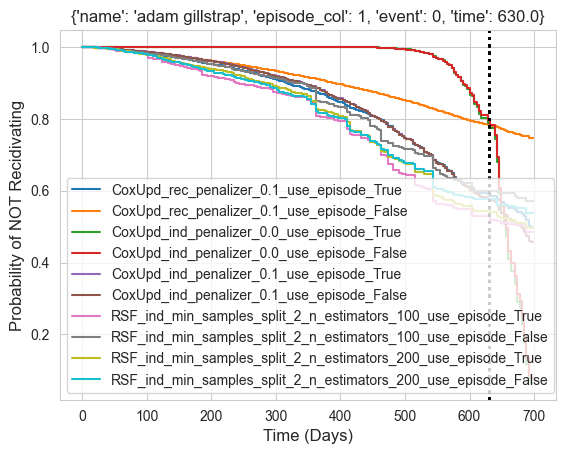

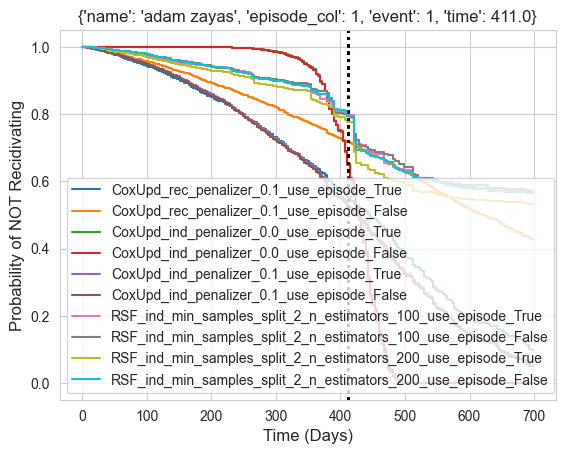

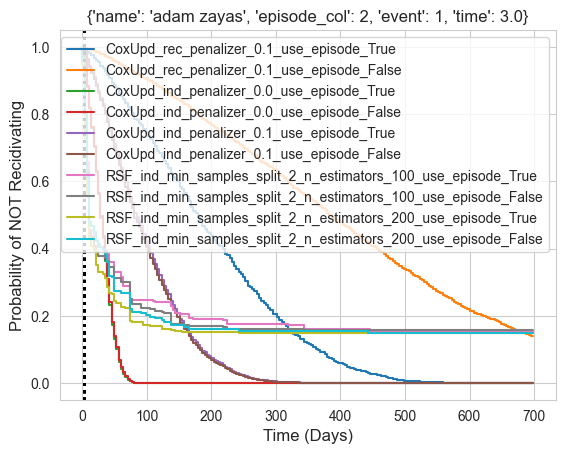

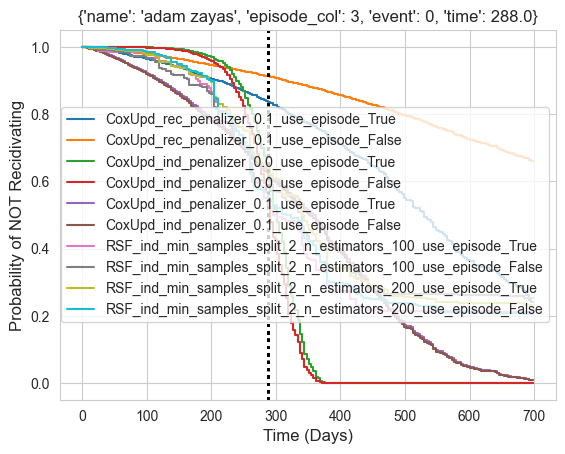

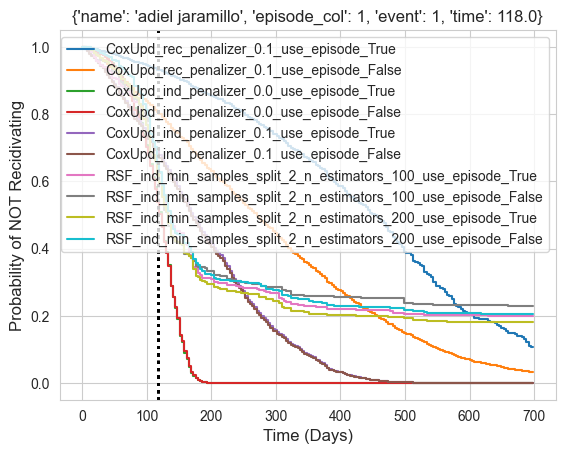

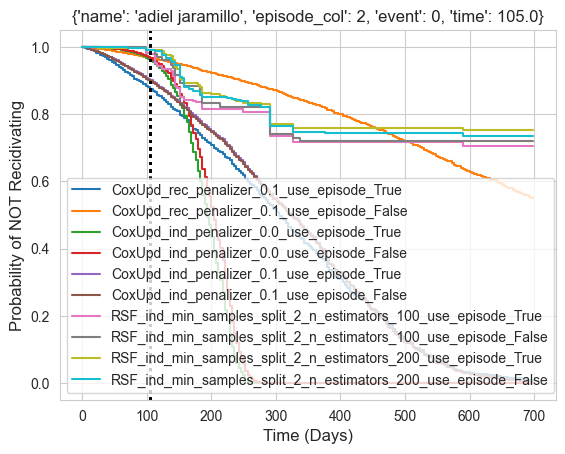

In [16]:
sns.set_style("whitegrid")

for index_test in range(10):
    for name, model in models.items():
        pred = model.predict_survival(test_model_df[features], times)
        plt.step(times, pred.iloc[index_test].values, label=name)
        sample_info = test_model_df.iloc[index_test]
        event_status = "Recidivated" if sample_info["event"] == 1 else "No Recidivism"
        time_to_event = sample_info["time"]
        plt.axvline(
            x=time_to_event,
            color="black",
            linestyle=":",
            linewidth=2,
        )
    # pred = rsf_model.predict_survival(test_model_df[rsf_model.features], times)
    # plt.step(times, pred.iloc[index_test].values, label="RSF_no_episode_col", color="red", linewidth=2)
    # sample_info = test_model_df.iloc[index_test]
    plt.xlabel("Time (Days)", fontsize=12)
    plt.ylabel("Probability of NOT Recidivating", fontsize=12)
    plt.legend()
    plt.title(f"{test_model_df.iloc[index_test][['name', 'episode_col', 'event', 'time']].to_dict()}")
    plt.show()